# Comparison of Three Coordination Schemes for the Mini Water-Energy Problem

This notebook compares three models for coordinating a water operator and an energy operator, based on the provided document:
1. **Centralized Coordination**: One operator owns everything.
2. **Decentralized Uncoordinated**: Water operator optimizes independently without seeing the peak penalty.
3. **Decentralized Coordinated**: Water operator optimizes with a peak penalty $\lambda$ passed down (where $\lambda = lpha$).

## Parameters
- $T = 6$
- $d^w_t = 2$ for all $t$
- $\kappa = 1$
- $ar{Q} = 5$
- $S^{\max} = 4$
- $S^{\min} = 0$, $s_0 = 0$
- $c_t = [1, 1, 2, 4, 4, 2]$
- $lpha = 3$


In [1]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import matplotlib.pyplot as plt

# Monkey-patch for tikzplotlib compatibility with matplotlib 3.8+ and numpy 2.0+
import matplotlib.backends.backend_pgf
if not hasattr(matplotlib.backends.backend_pgf, 'common_texification'):
    matplotlib.backends.backend_pgf.common_texification = lambda x: x

import matplotlib.legend
if not hasattr(matplotlib.legend.Legend, 'legendHandles'):
    matplotlib.legend.Legend.legendHandles = property(lambda self: self.legend_handles)
if not hasattr(matplotlib.legend.Legend, '_ncol'):
    matplotlib.legend.Legend._ncol = property(lambda self: self._ncols)

import matplotlib.lines
if not hasattr(matplotlib.lines.Line2D, '_us_dashSeq'):
    matplotlib.lines.Line2D._us_dashSeq = property(lambda self: self._dash_pattern[1])
    matplotlib.lines.Line2D._us_dashOffset = property(lambda self: self._dash_pattern[0])

import numpy as np
if not hasattr(np, 'float_'):
    np.float_ = np.float64

import tikzplotlib

# Parameters
T = 6
time_periods = range(T)
d_w = [2] * T
kappa = 1
Q_bar = 5
S_max = 4
S_min = 0
s_0 = 0
c = [1, 1, 2, 4, 4, 2]
alpha = 3
marginal_profit = 0  # Assuming 0 for the uncoordinated case


## 1. Centralized Coordination
The objective is to minimize total procurement cost plus the peak penalty.


In [2]:
m1 = gp.Model("Centralized_Coordination")
m1.Params.OutputFlag = 0

q1 = m1.addVars(T, lb=0, ub=Q_bar, name="q")
s1 = m1.addVars(T, lb=S_min, ub=S_max, name="s")
e1 = m1.addVars(T, lb=0, name="e")
E_max1 = m1.addVar(lb=0, name="E_max")

# Constraints
for t in time_periods:
    if t == 0:
        m1.addConstr(s1[t] == s_0 + q1[t] - d_w[t], name=f"water_balance_{t}")
    else:
        m1.addConstr(s1[t] == s1[t-1] + q1[t] - d_w[t], name=f"water_balance_{t}")
        
    m1.addConstr(e1[t] == kappa * q1[t], name=f"energy_req_{t}")
    m1.addConstr(E_max1 >= e1[t], name=f"peak_load_{t}")

m1.addConstr(s1[T-1] >= s_0, name="final_tank_level")

# Objective
obj1 = gp.quicksum(c[t] * e1[t] for t in time_periods) + alpha * E_max1
m1.setObjective(obj1, GRB.MINIMIZE)

m1.optimize()

print("--- Centralized Coordination Results ---")
print(f"Objective Value (Total System Cost): ${m1.ObjVal:.2f}")
total_energy_cost1 = sum(c[t] * e1[t].X for t in time_periods)
peak_cost1 = alpha * E_max1.X
print(f"Total Energy Cost: ${total_energy_cost1:.2f}")
print(f"Peak Cost: ${peak_cost1:.2f}")
print(f"Peak Load: {E_max1.X:.2f} kW")
res1 = pd.DataFrame({
    'Hour': [t+1 for t in time_periods],
    'Pump (q)': [q1[t].X for t in time_periods],
    'Tank (s)': [s1[t].X for t in time_periods],
    'Energy (e)': [e1[t].X for t in time_periods],
    'Price (c)': c
})
display(res1)


Set parameter Username
Set parameter LicenseID to value 2831429
Academic license - for non-commercial use only - expires 2027-06-05
--- Centralized Coordination Results ---
Objective Value (Total System Cost): $27.33
Total Energy Cost: $17.33
Peak Cost: $10.00
Peak Load: 3.33 kW


,Hour,Pump (q),Tank (s),Energy (e),Price (c)
0,1,3.333333,1.333333,3.333333,1
1,2,3.333333,2.666667,3.333333,1
2,3,3.333333,4.000000,3.333333,2
3,4,0.000000,2.000000,0.000000,4
4,5,0.000000,0.000000,0.000000,4
5,6,2.000000,0.000000,2.000000,2


## 2. Decentralized Uncoordinated
The water operator minimizes its own cost without considering the peak penalty. The energy operator provides electricity at price $p_t = c_t + 	ext{marginal}$.


In [3]:
m2 = gp.Model("Decentralized_Uncoordinated")
m2.Params.OutputFlag = 0

q2 = m2.addVars(T, lb=0, ub=Q_bar, name="q")
s2 = m2.addVars(T, lb=S_min, ub=S_max, name="s")
e2 = m2.addVars(T, lb=0, name="e")

p = [ct + marginal_profit for ct in c]

# Constraints
for t in time_periods:
    if t == 0:
        m2.addConstr(s2[t] == s_0 + q2[t] - d_w[t])
    else:
        m2.addConstr(s2[t] == s2[t-1] + q2[t] - d_w[t])
        
    m2.addConstr(e2[t] == kappa * q2[t])

m2.addConstr(s2[T-1] >= s_0)

# Objective (Water operator's view)
obj2 = gp.quicksum(p[t] * e2[t] for t in time_periods)
m2.setObjective(obj2, GRB.MINIMIZE)

m2.optimize()

# Calculate true system cost
total_energy_cost2 = sum(c[t] * e2[t].X for t in time_periods)
E_max2_val = max(e2[t].X for t in time_periods)
peak_cost2 = alpha * E_max2_val
true_system_cost2 = total_energy_cost2 + peak_cost2

print("--- Decentralized Uncoordinated Results ---")
print(f"Water Operator's Apparent Objective: ${m2.ObjVal:.2f}")
print(f"True Total System Cost: ${true_system_cost2:.2f}")
print(f"Total Energy Cost: ${total_energy_cost2:.2f}")
print(f"Peak Cost: ${peak_cost2:.2f}")
print(f"Peak Load: {E_max2_val:.2f} kW")
res2 = pd.DataFrame({
    'Hour': [t+1 for t in time_periods],
    'Pump (q)': [q2[t].X for t in time_periods],
    'Tank (s)': [s2[t].X for t in time_periods],
    'Energy (e)': [e2[t].X for t in time_periods],
    'Price (c)': c
})
display(res2)


--- Decentralized Uncoordinated Results ---
Water Operator's Apparent Objective: $16.00
True Total System Cost: $31.00
Total Energy Cost: $16.00
Peak Cost: $15.00
Peak Load: 5.00 kW


,Hour,Pump (q),Tank (s),Energy (e),Price (c)
0,1,3.0,1.0,3.0,1
1,2,5.0,4.0,5.0,1
2,3,2.0,4.0,2.0,2
3,4,0.0,2.0,0.0,4
4,5,0.0,0.0,0.0,4
5,6,2.0,0.0,2.0,2


## 3. Decentralized Coordinated
The energy operator passes a dual price $\lambda$ to the water operator for the peak capacity contribution. Here we use $\lambda = lpha$.


In [4]:
m3 = gp.Model("Decentralized_Coordinated")
m3.Params.OutputFlag = 0

q3 = m3.addVars(T, lb=0, ub=Q_bar, name="q")
s3 = m3.addVars(T, lb=S_min, ub=S_max, name="s")
e3 = m3.addVars(T, lb=0, name="e")
E_max3 = m3.addVar(lb=0, name="E_max")

lam = alpha  # Dual price for peak capacity

# Constraints
for t in time_periods:
    if t == 0:
        m3.addConstr(s3[t] == s_0 + q3[t] - d_w[t])
    else:
        m3.addConstr(s3[t] == s3[t-1] + q3[t] - d_w[t])
        
    m3.addConstr(e3[t] == kappa * q3[t])
    m3.addConstr(E_max3 >= e3[t])

m3.addConstr(s3[T-1] >= s_0)

# Objective (Water operator with coordination signal)
obj3 = gp.quicksum(p[t] * q3[t] for t in time_periods) + lam * E_max3
m3.setObjective(obj3, GRB.MINIMIZE)

m3.optimize()

# Calculate true system cost
total_energy_cost3 = sum(c[t] * e3[t].X for t in time_periods)
peak_cost3 = alpha * E_max3.X
true_system_cost3 = total_energy_cost3 + peak_cost3

print("--- Decentralized Coordinated Results ---")
print(f"Objective Value (Water Operator): ${m3.ObjVal:.2f}")
print(f"True Total System Cost: ${true_system_cost3:.2f}")
print(f"Total Energy Cost: ${total_energy_cost3:.2f}")
print(f"Peak Cost: ${peak_cost3:.2f}")
print(f"Peak Load: {E_max3.X:.2f} kW")
res3 = pd.DataFrame({
    'Hour': [t+1 for t in time_periods],
    'Pump (q)': [q3[t].X for t in time_periods],
    'Tank (s)': [s3[t].X for t in time_periods],
    'Energy (e)': [e3[t].X for t in time_periods],
    'Price (c)': c
})
display(res3)


--- Decentralized Coordinated Results ---
Objective Value (Water Operator): $27.33
True Total System Cost: $27.33
Total Energy Cost: $17.33
Peak Cost: $10.00
Peak Load: 3.33 kW


,Hour,Pump (q),Tank (s),Energy (e),Price (c)
0,1,3.333333,1.333333,3.333333,1
1,2,3.333333,2.666667,3.333333,1
2,3,3.333333,4.000000,3.333333,2
3,4,0.000000,2.000000,0.000000,4
4,5,0.000000,0.000000,0.000000,4
5,6,2.000000,0.000000,2.000000,2


## Comparison Summary


,Model,System Cost ($),Energy Cost ($),Peak Cost ($),Peak Load (kW)
0,Centralized,27.333333,17.333333,10.0,3.333333
1,Decentralized Uncoordinated,31.000000,16.000000,15.0,5.000000
2,Decentralized Coordinated,27.333333,17.333333,10.0,3.333333


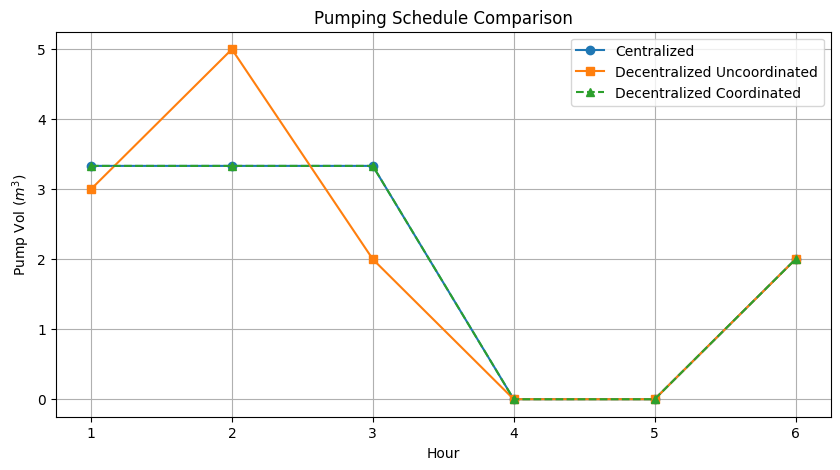

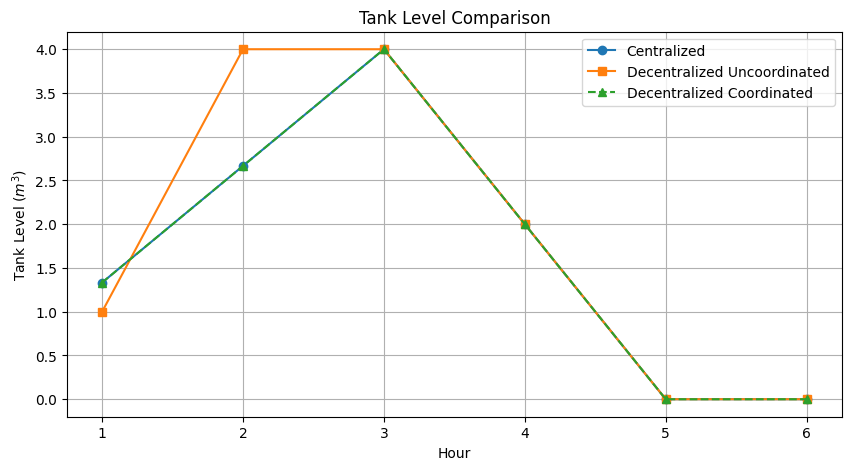

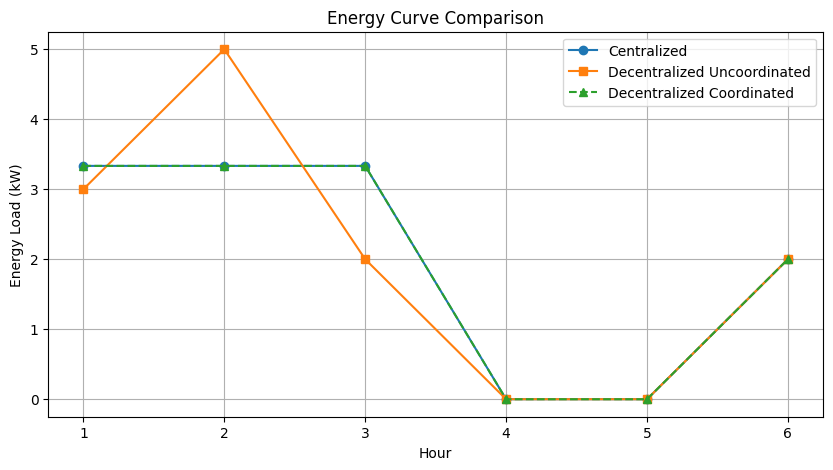

In [5]:
summary_data = {
    'Model': ['Centralized', 'Decentralized Uncoordinated', 'Decentralized Coordinated'],
    'System Cost ($)': [m1.ObjVal, true_system_cost2, true_system_cost3],
    'Energy Cost ($)': [total_energy_cost1, total_energy_cost2, total_energy_cost3],
    'Peak Cost ($)': [peak_cost1, peak_cost2, peak_cost3],
    'Peak Load (kW)': [E_max1.X, E_max2_val, E_max3.X]
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Plotting pump schedules
plt.figure(figsize=(10, 5))
plt.plot(res1['Hour'], res1['Pump (q)'], label='Centralized', marker='o')
plt.plot(res2['Hour'], res2['Pump (q)'], label='Decentralized Uncoordinated', marker='s')
plt.plot(res3['Hour'], res3['Pump (q)'], label='Decentralized Coordinated', marker='^', linestyle='--')
plt.xlabel('Hour')
plt.ylabel('Pump Vol ($m^3$)')
plt.title('Pumping Schedule Comparison')
plt.legend()
plt.grid(True)
tikzplotlib.save("pumping_schedule.tex")
plt.show()

# Plotting tank levels
plt.figure(figsize=(10, 5))
plt.plot(res1['Hour'], res1['Tank (s)'], label='Centralized', marker='o')
plt.plot(res2['Hour'], res2['Tank (s)'], label='Decentralized Uncoordinated', marker='s')
plt.plot(res3['Hour'], res3['Tank (s)'], label='Decentralized Coordinated', marker='^', linestyle='--')
plt.xlabel('Hour')
plt.ylabel('Tank Level ($m^3$)')
plt.title('Tank Level Comparison')
plt.legend()
plt.grid(True)
tikzplotlib.save("tank_level.tex")
plt.show()

# Plotting energy curves
plt.figure(figsize=(10, 5))
plt.plot(res1['Hour'], res1['Energy (e)'], label='Centralized', marker='o')
plt.plot(res2['Hour'], res2['Energy (e)'], label='Decentralized Uncoordinated', marker='s')
plt.plot(res3['Hour'], res3['Energy (e)'], label='Decentralized Coordinated', marker='^', linestyle='--')
plt.xlabel('Hour')
plt.ylabel('Energy Load (kW)')
plt.title('Energy Curve Comparison')
plt.legend()
plt.grid(True)
tikzplotlib.save("energy_curve.tex")
plt.show()
